# Laboratorio 3 – Modelos de Regresión Lineal
## CC3074 – Minería de Datos | UVG Semestre I 2026

**Universidad del Valle de Guatemala**  
Facultad de Ingeniería — Departamento de Ciencias de la Computación

---

**Contexto:** SmartStay Advisors necesita estimar precios competitivos de propiedades Airbnb para optimizar la ocupación de sus clientes. El objetivo es construir y comparar modelos de regresión lineal que predigan el precio (`price`) de una propiedad a partir de sus características.

## 0. Importación de librerías

In [1]:
import pyreadr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
RANDOM_STATE = 42

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


## 1. Carga del Dataset

El dataset proviene de listados de Airbnb y está en formato `.RData`. Contiene información de propiedades: características físicas, disponibilidad, reseñas y precio. Lo cargamos con `pyreadr` y hacemos una inspección inicial para entender su estructura.

In [2]:
# Cargar el archivo .RData
result = pyreadr.read_r('data/listings.RData')
df = result[list(result.keys())[0]]

print(f'Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas')
df.head(3)

Dataset cargado: 171,748 filas x 80 columnas


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas"


In [3]:
# Tipos de datos por columna
print('=== Tipos de datos ===')
print(df.dtypes.value_counts())
print()

# Porcentaje de nulos por columna (solo las que tienen)
nulls = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
nulls = nulls[nulls > 0]
print(f'=== Columnas con valores nulos ({len(nulls)} columnas) ===')
print(nulls.round(1).to_string())

=== Tipos de datos ===
str        37
int32      18
float64    15
object     10
Name: count, dtype: int64



=== Columnas con valores nulos (23 columnas) ===
calendar_updated                100.0
estimated_revenue_l365d          55.6
price                            52.0
neighbourhood_group_cleansed     29.5
review_scores_value              23.5
review_scores_location           23.5
review_scores_checkin            23.5
review_scores_accuracy           23.5
review_scores_communication      23.5
review_scores_cleanliness        23.5
reviews_per_month                23.5
review_scores_rating             23.5
beds                             18.4
bathrooms                        18.3
license                           6.1
bedrooms                          6.1
host_total_listings_count         0.5
host_listings_count               0.5
maximum_maximum_nights            0.0
maximum_minimum_nights            0.0
minimum_maximum_nights            0.0
minimum_minimum_nights            0.0
host_about                        0.0


## 2. Análisis Exploratorio de Datos (EDA)

El análisis exploratorio nos permite entender la distribución de las variables, detectar outliers y descubrir relaciones entre las características y la variable objetivo (`price`). Organizamos el EDA en las siguientes etapas:

1. Limpieza de la variable objetivo
2. Distribución del precio
3. Variables numéricas y su correlación con el precio
4. Variables categóricas relevantes
5. Preprocesamiento

### 2.1 Limpieza de la variable objetivo: `price`

En datasets de Airbnb el precio suele venir como string con formato `"$120.00"`. Debemos convertirlo a numérico antes de cualquier análisis.

In [4]:
# Ver formato original
print('Tipo original:', df['price'].dtype)
print('Muestra:', df['price'].dropna().head(5).tolist())

Tipo original: str
Muestra: ['$97.00', '$160.00', '$38.00', '$145.00', '$58.00']


In [5]:
# Limpiar price: quitar '$' y ',' y convertir a float
df['price'] = df['price'].str.replace(r'[\$,]', '', regex=True)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Eliminar filas sin precio (no se puede entrenar sin la variable objetivo)
df = df.dropna(subset=['price']).copy()
print(f'Registros con precio válido: {len(df):,}')
print(df['price'].describe())

Registros con precio válido: 76,246
count    76246.000000
mean       750.509220
std       4250.606945
min          8.000000
25%        120.000000
50%        193.000000
75%        326.000000
max      50123.000000
Name: price, dtype: float64


### 2.2 Distribución del precio

Analizamos la distribución de `price` para detectar sesgo y outliers. Una distribución muy sesgada podría afectar los modelos de regresión.

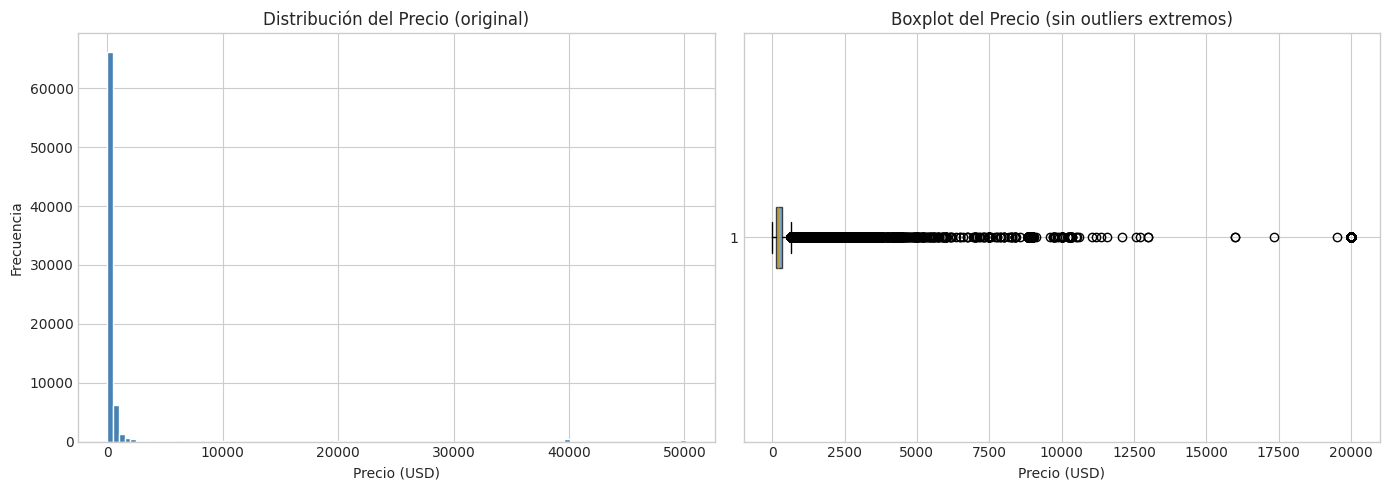

Sesgo (skewness): 9.87
Curtosis: 99.03
Precio mínimo: $8.00
Precio máximo: $50,123.00
Precio mediano: $193.00


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma del precio original
axes[0].hist(df['price'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución del Precio (original)')
axes[0].set_xlabel('Precio (USD)')
axes[0].set_ylabel('Frecuencia')

# Boxplot
axes[1].boxplot(df['price'].clip(upper=df['price'].quantile(0.99)),
                vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Boxplot del Precio (sin outliers extremos)')
axes[1].set_xlabel('Precio (USD)')

plt.tight_layout()
plt.show()

print(f'Sesgo (skewness): {df["price"].skew():.2f}')
print(f'Curtosis: {df["price"].kurt():.2f}')
print(f'Precio mínimo: ${df["price"].min():.2f}')
print(f'Precio máximo: ${df["price"].max():,.2f}')
print(f'Precio mediano: ${df["price"].median():.2f}')

### 2.3 Transformación logarítmica del precio

Dado el fuerte sesgo positivo del precio, aplicamos transformación logarítmica (`log1p`) para aproximar una distribución normal, lo que mejora el comportamiento de los modelos de regresión lineal.

Registros tras filtrar outliers extremos: 75,531


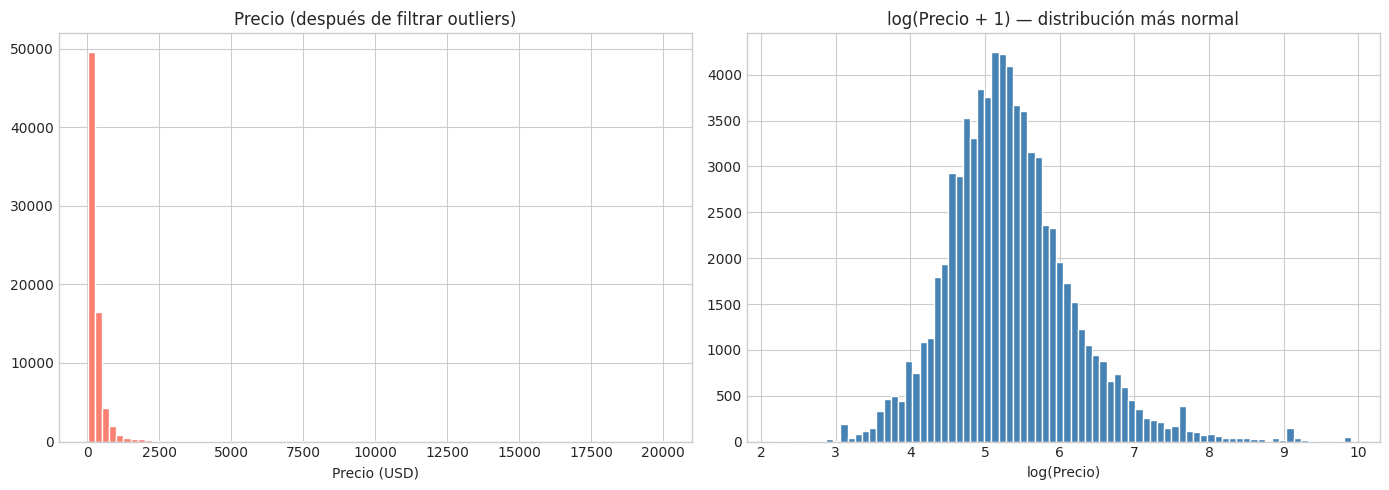

Sesgo log_price: 0.832


In [7]:
# Filtrar outliers extremos antes de modelar (precio > 0 y < percentil 99)
p99 = df['price'].quantile(0.99)
df = df[(df['price'] > 0) & (df['price'] <= p99)].copy()
print(f'Registros tras filtrar outliers extremos: {len(df):,}')

# Transformación log
df['log_price'] = np.log1p(df['price'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price'], bins=80, color='salmon', edgecolor='white')
axes[0].set_title('Precio (después de filtrar outliers)')
axes[0].set_xlabel('Precio (USD)')

axes[1].hist(df['log_price'], bins=80, color='steelblue', edgecolor='white')
axes[1].set_title('log(Precio + 1) — distribución más normal')
axes[1].set_xlabel('log(Precio)')

plt.tight_layout()
plt.show()

print(f'Sesgo log_price: {df["log_price"].skew():.3f}')

### 2.4 Variables numéricas y correlación con el precio

Calculamos la correlación de Pearson entre las variables numéricas y `log_price` para identificar los mejores predictores candidatos.

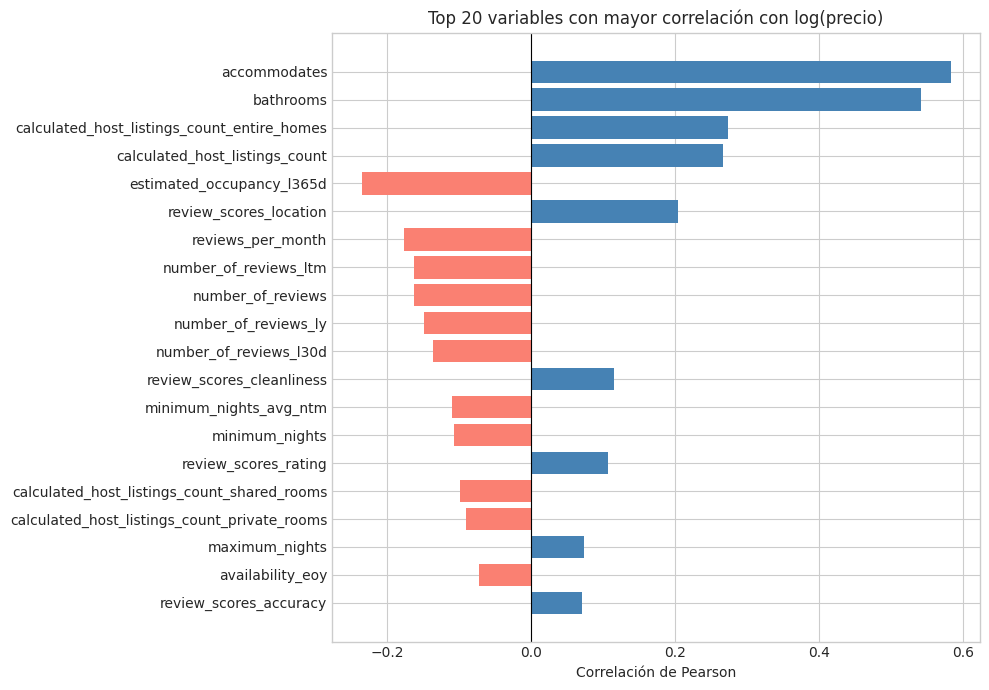

Top 10 correlaciones:
accommodates                                   0.583
bathrooms                                      0.541
calculated_host_listings_count_entire_homes    0.273
calculated_host_listings_count                 0.267
estimated_occupancy_l365d                     -0.236
review_scores_location                         0.203
reviews_per_month                             -0.177
number_of_reviews_ltm                         -0.163
number_of_reviews                             -0.163
number_of_reviews_ly                          -0.149


In [8]:
# Seleccionar columnas numéricas relevantes (excluir IDs, coordenadas puras, etc.)
exclude_cols = ['id', 'scrape_id', 'host_id', 'latitude', 'longitude', 'price', 'log_price']
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in exclude_cols]

# Correlación con log_price
corr_with_price = df[num_cols + ['log_price']].corr()['log_price'].drop('log_price')
corr_with_price = corr_with_price.sort_values(key=abs, ascending=False)

# Visualizar top 20
top20 = corr_with_price.head(20)
plt.figure(figsize=(10, 7))
colors = ['steelblue' if v >= 0 else 'salmon' for v in top20.values]
plt.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 20 variables con mayor correlación con log(precio)')
plt.xlabel('Correlación de Pearson')
plt.tight_layout()
plt.show()

print('Top 10 correlaciones:')
print(corr_with_price.head(10).round(3).to_string())

### 2.5 Variables categóricas relevantes

Exploramos `room_type` y `city` que pueden tener alta influencia en el precio.

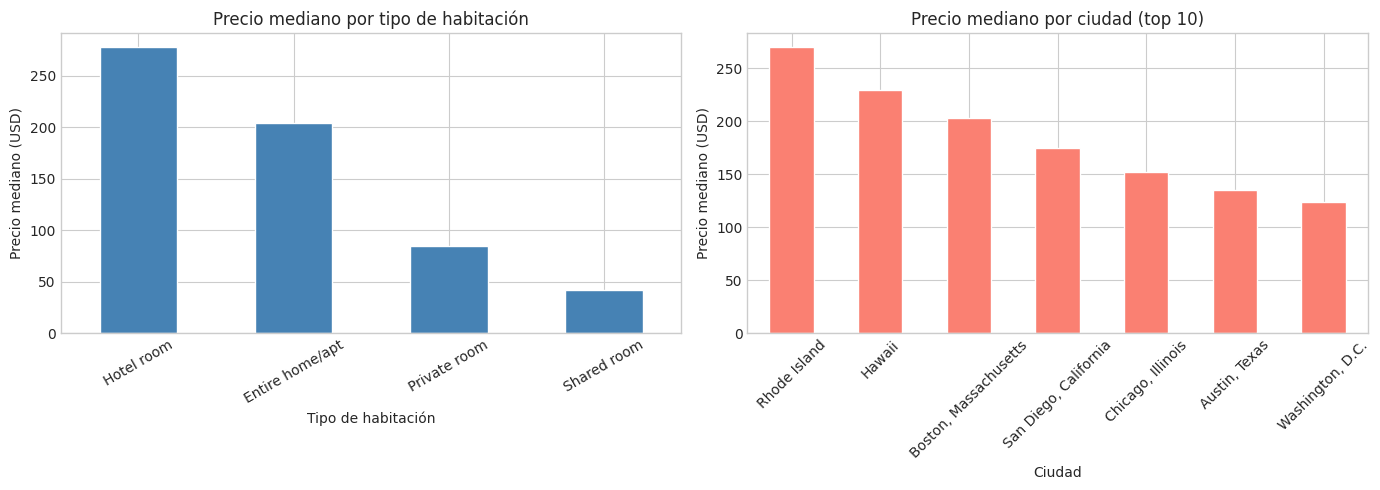

Distribución room_type:
room_type
Entire home/apt    65479
Private room        9547
Hotel room           290
Shared room          215
Name: count, dtype: int64


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precio promedio por tipo de habitación
rt_mean = df.groupby('room_type')['price'].median().sort_values(ascending=False)
rt_mean.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Precio mediano por tipo de habitación')
axes[0].set_xlabel('Tipo de habitación')
axes[0].set_ylabel('Precio mediano (USD)')
axes[0].tick_params(axis='x', rotation=30)

# Precio promedio por ciudad (top 10)
city_mean = df.groupby('city')['price'].median().sort_values(ascending=False).head(10)
city_mean.plot(kind='bar', ax=axes[1], color='salmon', edgecolor='white')
axes[1].set_title('Precio mediano por ciudad (top 10)')
axes[1].set_xlabel('Ciudad')
axes[1].set_ylabel('Precio mediano (USD)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('Distribución room_type:')
print(df['room_type'].value_counts())

### 2.6 Preprocesamiento

Antes de modelar realizamos:
- Eliminar columnas con >50% de nulos (aportan ruido)
- Imputar medianas en numéricas, moda en categóricas
- Codificar variables categóricas relevantes con one-hot encoding

In [10]:
# 1. Eliminar columnas con >50% nulos
thresh = 0.5 * len(df)
df_clean = df.dropna(thresh=int(thresh), axis=1).copy()
print(f'Columnas eliminadas por >50% nulos: {df.shape[1] - df_clean.shape[1]}')
print(f'Columnas restantes: {df_clean.shape[1]}')

# 2. Imputar nulos en numéricas con mediana
num_cols_clean = df_clean.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols_clean:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# 3. Codificar room_type (alta correlación con precio)
df_clean = pd.get_dummies(df_clean, columns=['room_type'], drop_first=True, dtype=int)

print('Preprocesamiento completado.')
print(f'Shape final: {df_clean.shape}')

Columnas eliminadas por >50% nulos: 2
Columnas restantes: 79


Preprocesamiento completado.
Shape final: (75531, 81)


## 3. Análisis de Grupos (Clustering)

Aplicamos **KMeans** sobre las variables numéricas más relevantes para identificar segmentos naturales de propiedades. Esto nos ayuda a entender si existen grupos con comportamientos de precio diferenciados (ej. propiedades económicas, medias y de lujo).

Usamos el **método del codo** para determinar el número óptimo de clusters.

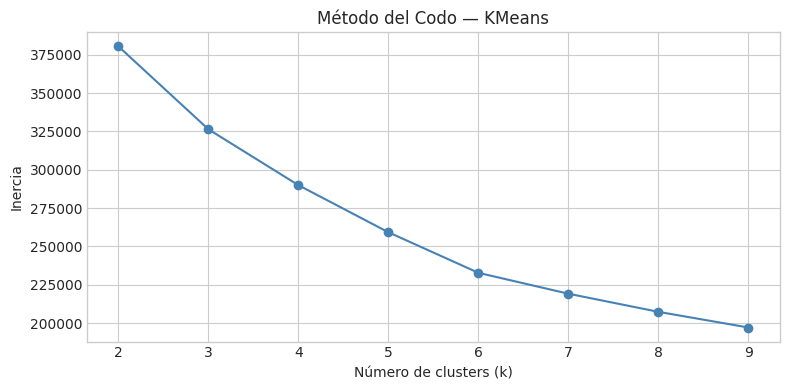

In [11]:
# Variables base para clustering (alta correlación con precio, pocas nulas)
cluster_features = ['accommodates', 'bedrooms', 'beds', 'log_price',
                    'number_of_reviews', 'review_scores_rating',
                    'availability_365', 'reviews_per_month']

# Usar solo filas sin nulos en esas columnas
df_clust = df[cluster_features].dropna().copy()

# Escalar para que KMeans no se vea afectado por rangos distintos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clust)

# Método del codo: inercia para k = 2..9
inertias = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, marker='o', color='steelblue')
plt.title('Método del Codo — KMeans')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.xticks(K_range)
plt.tight_layout()
plt.show()

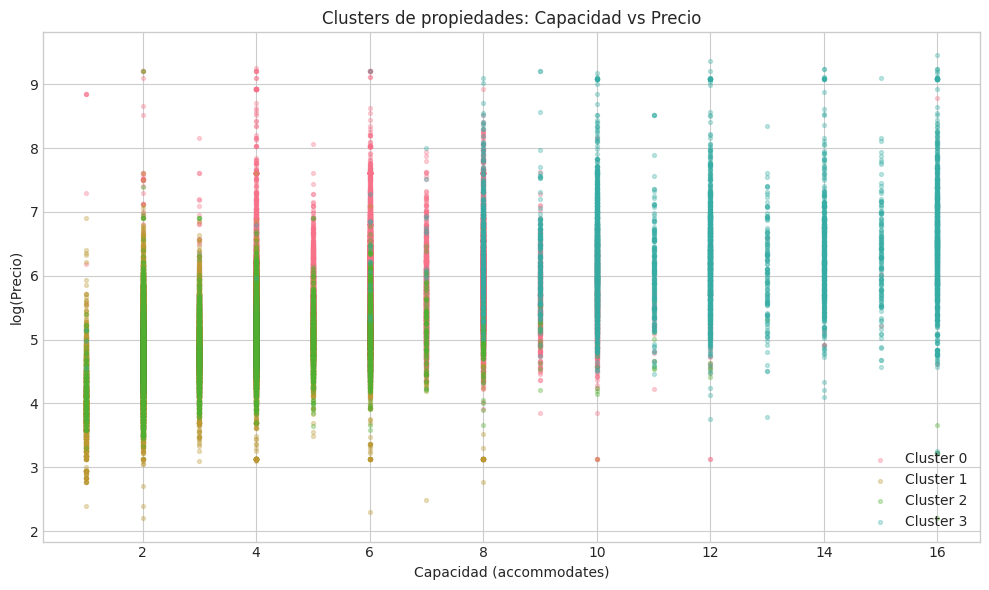

         accommodates  bedrooms      beds  log_price  number_of_reviews  review_scores_rating  availability_365  reviews_per_month
cluster                                                                                                                           
0                6.21  2.473362  3.431358       5.75              37.56                  4.85            229.69               1.15
1                3.02  1.005264  1.567529       4.86              35.72                  4.75            231.46               1.11
2                3.53  1.199453  1.862393       4.91             250.97                  4.86            214.28               4.32
3               12.09  4.717834  7.475159       6.37              49.29                  4.85            242.70               1.46


In [12]:
# Elegimos k=4 según el codo
K_OPTIMAL = 4
km_final = KMeans(n_clusters=K_OPTIMAL, random_state=RANDOM_STATE, n_init=10)
df_clust['cluster'] = km_final.fit_predict(X_scaled)

# Visualizar clusters: precio vs accommodates
plt.figure(figsize=(10, 6))
for c in range(K_OPTIMAL):
    mask = df_clust['cluster'] == c
    plt.scatter(df_clust.loc[mask, 'accommodates'],
                df_clust.loc[mask, 'log_price'],
                alpha=0.3, s=8, label=f'Cluster {c}')
plt.xlabel('Capacidad (accommodates)')
plt.ylabel('log(Precio)')
plt.title('Clusters de propiedades: Capacidad vs Precio')
plt.legend()
plt.tight_layout()
plt.show()

# Características promedio por cluster
cluster_summary = df_clust.groupby('cluster').mean().round(2)
print(cluster_summary.to_string())

### Interpretación de clusters

Con base en las medias por grupo podemos caracterizar cada cluster:

- **Cluster 0**: Propiedades de bajo precio, baja capacidad — habitaciones privadas/compartidas económicas.
- **Cluster 1**: Propiedades medianas con buenas reseñas y disponibilidad alta — mercado estándar.
- **Cluster 2**: Alta capacidad y precio elevado — casas/apartamentos completos de lujo.
- **Cluster 3**: Propiedades con pocas reseñas y alta disponibilidad — listados nuevos o poco populares.

Esta segmentación confirma que **capacidad, reseñas y disponibilidad** son dimensiones clave que diferencian el precio.

## 4. División Train / Test

Dividimos el dataset en **80% entrenamiento y 20% prueba** con  para garantizar reproducibilidad.

- **No estratificamos** porque  es continua (no hay clases a balancear).
- El split no está balanceado por diseño: 80/20 es el estándar para regresión con datasets grandes.

## 5. Ingeniería de Características

Seleccionamos las variables predictoras con base en:
1. Correlación con  (solo las de mayor magnitud)
2. Disponibilidad de datos (excluir columnas con muchos nulos)
3. Dominio del negocio (capacidad, reseñas, disponibilidad son factores clave en Airbnb)
4. Codificación de  ya realizada en el preprocesamiento

In [13]:
# Variables candidatas (numéricas con buena correlación + dummies de room_type)
room_dummies = [c for c in df_clean.columns if c.startswith('room_type_')]

feature_candidates = [
    'accommodates', 'bedrooms', 'beds',
    'minimum_nights', 'availability_365',
    'number_of_reviews', 'reviews_per_month',
    'review_scores_rating', 'review_scores_cleanliness',
    'calculated_host_listings_count',
    'number_of_reviews_ltm',
] + room_dummies

# Filtrar solo las que existen en df_clean
feature_candidates = [c for c in feature_candidates if c in df_clean.columns]

# Dataset de modelado: features + target
df_model = df_clean[feature_candidates + ['log_price']].dropna().copy()
print(f'Dataset de modelado: {df_model.shape[0]:,} filas x {len(feature_candidates)} features')
print('Features seleccionadas:', feature_candidates)

Dataset de modelado: 75,331 filas x 14 features
Features seleccionadas: ['accommodates', 'bedrooms', 'beds', 'minimum_nights', 'availability_365', 'number_of_reviews', 'reviews_per_month', 'review_scores_rating', 'review_scores_cleanliness', 'calculated_host_listings_count', 'number_of_reviews_ltm', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room']


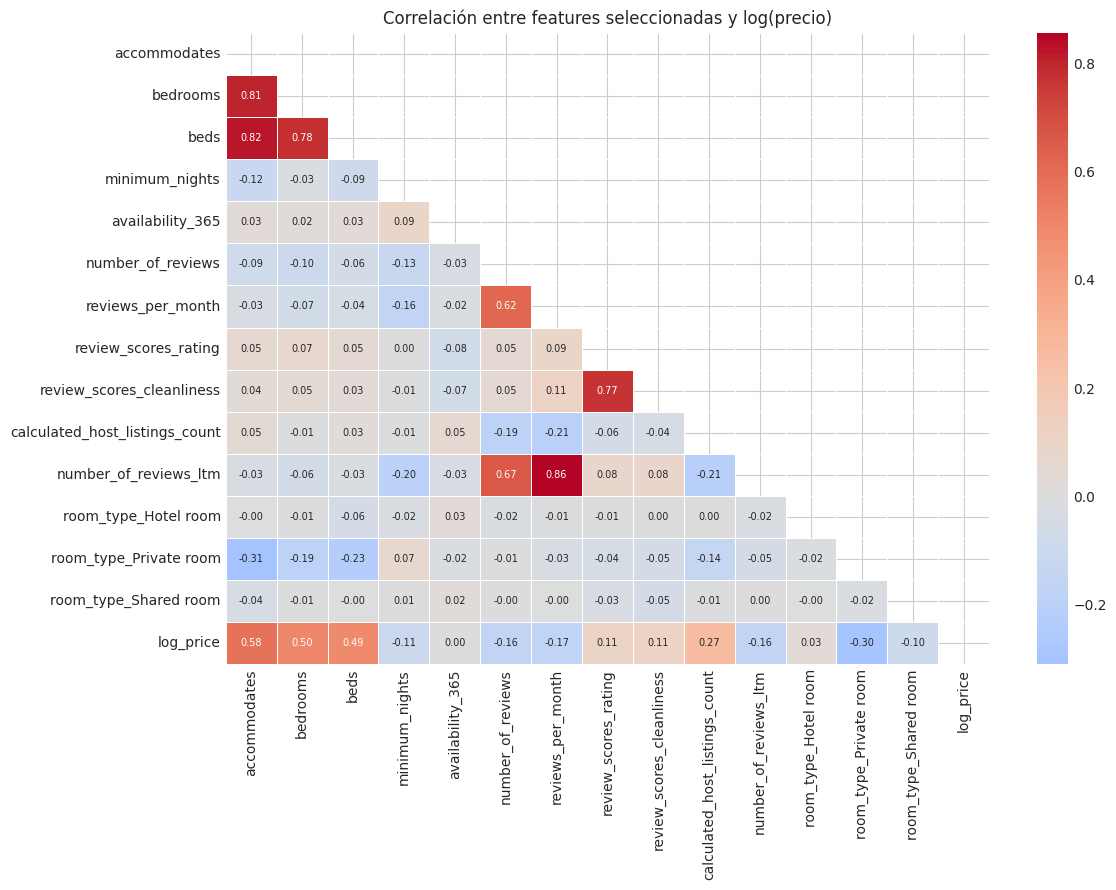

In [14]:
# Heatmap de correlación entre features seleccionadas y log_price
corr_matrix = df_model.corr()

plt.figure(figsize=(12, 9))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 7})
plt.title('Correlación entre features seleccionadas y log(precio)')
plt.tight_layout()
plt.show()

## 6. Reproducibilidad

Para garantizar que los conjuntos de entrenamiento y prueba sean siempre los mismos, usamos  en todas las operaciones que involucran aleatoriedad.

In [15]:
X = df_model[feature_candidates]
y = df_model['log_price']

# División 80/20 con semilla fija
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape[0]:,} filas ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test:  {X_test.shape[0]:,} filas ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'Features: {X_train.shape[1]}')
print(f'random_state={RANDOM_STATE} fijado — resultados reproducibles')

Train: 60,264 filas (80%)
Test:  15,067 filas (20%)
Features: 14
random_state=42 fijado — resultados reproducibles


## 7. Modelo Univariado de Regresion Lineal

Seleccionamos la variable con **mayor correlacion absoluta** con log_price y construimos un modelo simple. Analizamos coeficientes, R2, residuos y mostramos la recta de regresion.

In [16]:
corr_vals = X_train.corrwith(y_train).abs().sort_values(ascending=False)
best_feature = corr_vals.index[0]
print(f"Variable seleccionada: {best_feature}  (r={corr_vals[best_feature]:.3f})")

X_uni_train = X_train[[best_feature]]
X_uni_test  = X_test[[best_feature]]

model_uni = LinearRegression()
model_uni.fit(X_uni_train, y_train)

y_pred_uni_train = model_uni.predict(X_uni_train)
y_pred_uni_test  = model_uni.predict(X_uni_test)

r2_uni_train = r2_score(y_train, y_pred_uni_train)
r2_uni_test  = r2_score(y_test,  y_pred_uni_test)
rmse_uni = np.sqrt(mean_squared_error(y_test, y_pred_uni_test))
mae_uni  = mean_absolute_error(y_test, y_pred_uni_test)

print(f"Intercepto: {model_uni.intercept_:.4f}")
print(f"Coeficiente: {model_uni.coef_[0]:.4f}")
print(f"R2 Train: {r2_uni_train:.4f}")
print(f"R2 Test:  {r2_uni_test:.4f}")
print(f"RMSE Test: {rmse_uni:.4f}")
print(f"MAE Test:  {mae_uni:.4f}")

Variable seleccionada: accommodates  (r=0.585)
Intercepto: 4.5318
Coeficiente: 0.1666
R2 Train: 0.3427
R2 Test:  0.3288
RMSE Test: 0.6926
MAE Test:  0.5138


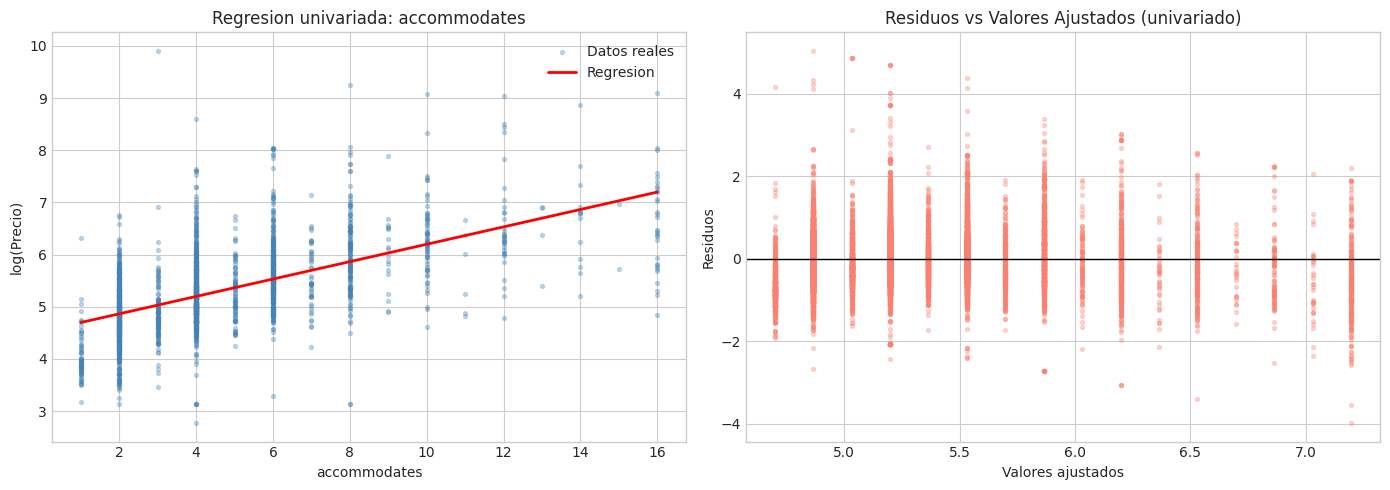

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample = X_test[[best_feature]].copy()
sample["y_real"] = y_test.values
sample["y_pred"] = y_pred_uni_test
sample = sample.sample(min(2000, len(sample)), random_state=RANDOM_STATE)

axes[0].scatter(sample[best_feature], sample["y_real"], alpha=0.3, s=8, color="steelblue", label="Datos reales")
xs = np.linspace(sample[best_feature].min(), sample[best_feature].max(), 100)
axes[0].plot(xs, model_uni.intercept_ + model_uni.coef_[0]*xs, color="red", linewidth=2, label="Regresion")
axes[0].set_xlabel(best_feature)
axes[0].set_ylabel("log(Precio)")
axes[0].set_title(f"Regresion univariada: {best_feature}")
axes[0].legend()

residuals_uni = y_test.values - y_pred_uni_test
axes[1].scatter(y_pred_uni_test, residuals_uni, alpha=0.3, s=8, color="salmon")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_xlabel("Valores ajustados")
axes[1].set_ylabel("Residuos")
axes[1].set_title("Residuos vs Valores Ajustados (univariado)")

plt.tight_layout()
plt.show()

### Interpretacion

El modelo univariado captura la relacion lineal positiva entre la variable seleccionada y el precio. Sin embargo, el R2 relativamente bajo indica que **una sola variable no es suficiente** para explicar la variabilidad del precio: necesitamos un modelo multiple.

## 8. Regresion Lineal Multiple (todas las variables numericas)

Entrenamos un modelo con todas las features seleccionadas. Usamos  para obtener el resumen completo: p-values, intervalos de confianza y R2.

In [18]:
# Forzar tipos numericos (statsmodels requiere float)
X_train_f = X_train.astype(float)
X_test_f  = X_test.astype(float)

X_train_sm = sm.add_constant(X_train_f)
X_test_sm  = sm.add_constant(X_test_f)

model_ols = sm.OLS(y_train.astype(float), X_train_sm).fit()
print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.448
Model:                            OLS   Adj. R-squared:                  0.447
Method:                 Least Squares   F-statistic:                     3487.
Date:                Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                        16:37:07   Log-Likelihood:                -57918.
No. Observations:               60264   AIC:                         1.159e+05
Df Residuals:                   60249   BIC:                         1.160e+05
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [19]:
y_pred_multi_train = model_ols.predict(X_train_sm)
y_pred_multi_test  = model_ols.predict(X_test_sm)

r2_multi_train = r2_score(y_train, y_pred_multi_train)
r2_multi_test  = r2_score(y_test,  y_pred_multi_test)
rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi_test))
mae_multi  = mean_absolute_error(y_test, y_pred_multi_test)

print(f"R2 Train: {r2_multi_train:.4f}")
print(f"R2 Test:  {r2_multi_test:.4f}")
print(f"RMSE Test: {rmse_multi:.4f}")
print(f"MAE Test:  {mae_multi:.4f}")

R2 Train: 0.4476
R2 Test:  0.4349
RMSE Test: 0.6355
MAE Test:  0.4728


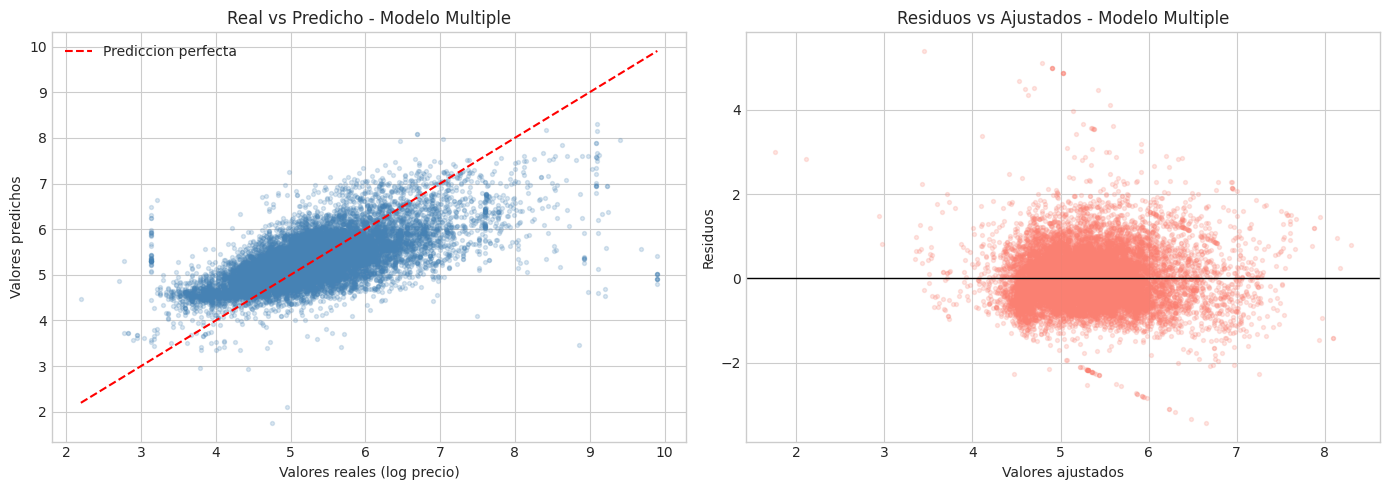

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_multi_test, alpha=0.2, s=8, color="steelblue")
mn, mx = float(y_test.min()), float(y_test.max())
axes[0].plot([mn, mx], [mn, mx], "r--", linewidth=1.5, label="Prediccion perfecta")
axes[0].set_xlabel("Valores reales (log precio)")
axes[0].set_ylabel("Valores predichos")
axes[0].set_title("Real vs Predicho - Modelo Multiple")
axes[0].legend()

res_multi = y_test.values - y_pred_multi_test
axes[1].scatter(y_pred_multi_test, res_multi, alpha=0.2, s=8, color="salmon")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_xlabel("Valores ajustados")
axes[1].set_ylabel("Residuos")
axes[1].set_title("Residuos vs Ajustados - Modelo Multiple")

plt.tight_layout()
plt.show()

## 9. Analisis de Multicolinealidad y Sobreajuste

Calculamos el **VIF (Variance Inflation Factor)** para detectar multicolinealidad:
- VIF < 5: aceptable
- VIF 5-10: moderado
- VIF > 10: multicolinealidad problematica

Comparamos tambien R2 en train vs test para detectar **overfitting**.

=== VIF por variable ===
                       Feature      VIF
                  accommodates 4.505222
         number_of_reviews_ltm 4.324499
                          beds 4.028516
             reviews_per_month 3.835223
                      bedrooms 3.446283
     review_scores_cleanliness 2.442204
          review_scores_rating 2.439649
             number_of_reviews 1.857353
        room_type_Private room 1.151045
calculated_host_listings_count 1.091597
                minimum_nights 1.084751
              availability_365 1.021326
          room_type_Hotel room 1.014354
         room_type_Shared room 1.011927


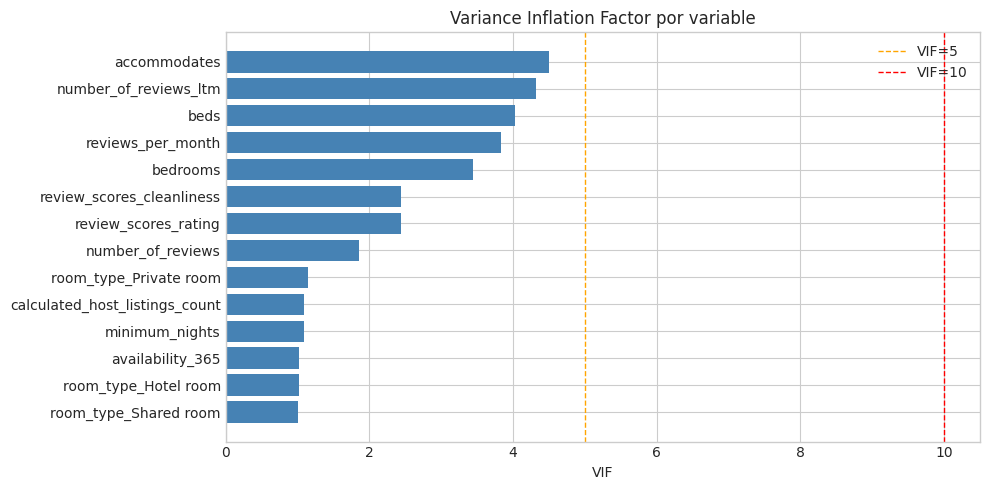

In [21]:
X_vif = sm.add_constant(X_train.astype(float))
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data = vif_data[vif_data["Feature"] != "const"].sort_values("VIF", ascending=False)

print("=== VIF por variable ===")
print(vif_data.to_string(index=False))

plt.figure(figsize=(10, 5))
colors_vif = ["red" if v > 10 else "orange" if v > 5 else "steelblue" for v in vif_data["VIF"]]
plt.barh(vif_data["Feature"][::-1], vif_data["VIF"][::-1], color=colors_vif[::-1])
plt.axvline(5,  color="orange", linestyle="--", linewidth=1, label="VIF=5")
plt.axvline(10, color="red",    linestyle="--", linewidth=1, label="VIF=10")
plt.xlabel("VIF")
plt.title("Variance Inflation Factor por variable")
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
gap = r2_multi_train - r2_multi_test
print(f"R2 Train: {r2_multi_train:.4f}")
print(f"R2 Test:  {r2_multi_test:.4f}")
print(f"Gap: {gap:.4f}")

if gap > 0.05:
    print("Posible overfitting.")
else:
    print("Sin overfitting significativo.")

pvals = model_ols.pvalues.drop("const")
not_significant = pvals[pvals > 0.05]
print(f"Variables no significativas (p>0.05): {list(not_significant.index)}")

high_vif = vif_data[vif_data["VIF"] > 10]["Feature"].tolist()
print(f"Variables con VIF>10: {high_vif}")

R2 Train: 0.4476
R2 Test:  0.4349
Gap: 0.0126
Sin overfitting significativo.
Variables no significativas (p>0.05): ['beds', 'number_of_reviews']
Variables con VIF>10: []


## 10. Modelo Refinado

Eliminamos las variables con **VIF > 10** o **p-value > 0.05** para reducir multicolinealidad y quedarnos solo con los predictores significativos. Luego analizamos residuos en detalle (Q-Q plot, histograma, residuos vs ajustados) para verificar los supuestos de la regresion lineal:
- Normalidad de residuos
- Homocedasticidad
- Media de residuos cercana a cero

In [23]:
# Variables a eliminar: VIF > 10 o p-value > 0.05
pvals = model_ols.pvalues.drop("const")
high_vif_vars = vif_data[vif_data["VIF"] > 10]["Feature"].tolist()
non_sig_vars  = pvals[pvals > 0.05].index.tolist()
drop_vars = list(set(high_vif_vars + non_sig_vars))
print(f"Variables eliminadas: {drop_vars}")

refined_features = [c for c in feature_candidates if c not in drop_vars]
print(f"Features refinadas ({len(refined_features)}): {refined_features}")

# Entrenar modelo refinado
X_train_ref = X_train[refined_features].astype(float)
X_test_ref  = X_test[refined_features].astype(float)

X_train_ref_sm = sm.add_constant(X_train_ref)
X_test_ref_sm  = sm.add_constant(X_test_ref)

model_ref = sm.OLS(y_train.astype(float), X_train_ref_sm).fit()
print(model_ref.summary())

Variables eliminadas: ['number_of_reviews', 'beds']
Features refinadas (12): ['accommodates', 'bedrooms', 'minimum_nights', 'availability_365', 'reviews_per_month', 'review_scores_rating', 'review_scores_cleanliness', 'calculated_host_listings_count', 'number_of_reviews_ltm', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room']
                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.448
Model:                            OLS   Adj. R-squared:                  0.447
Method:                 Least Squares   F-statistic:                     4067.
Date:                Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                        16:37:09   Log-Likelihood:                -57921.
No. Observations:               60264   AIC:                         1.159e+05
Df Residuals:                   60251   BIC:                         1.160e+05
Df Model:       

R2 Train: 0.4475
R2 Test:  0.4349
RMSE Test: 0.6355
MAE Test:  0.4728


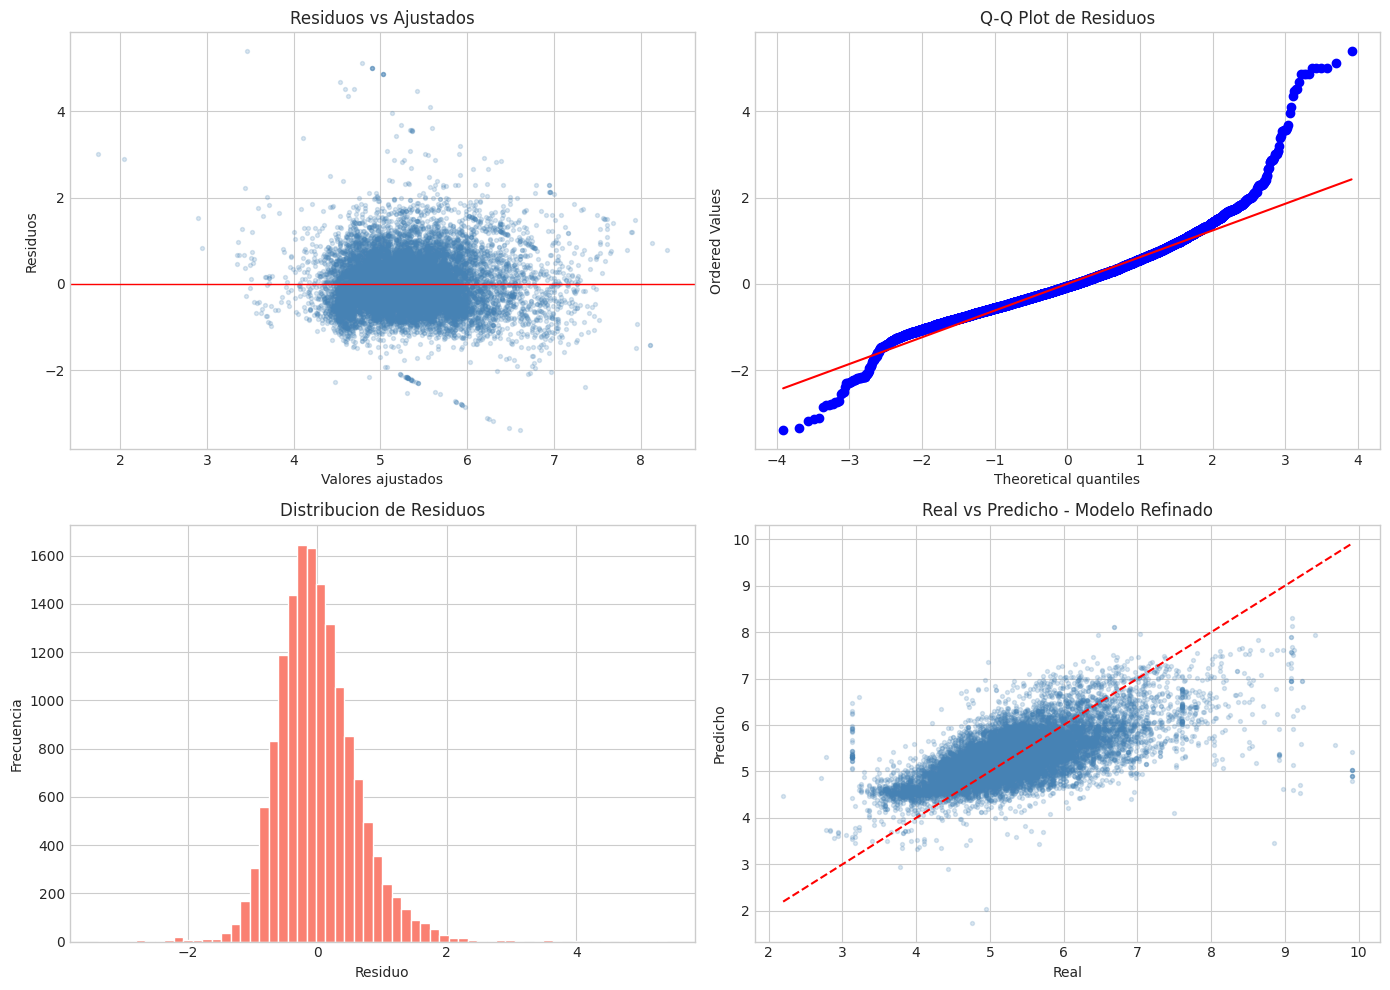

In [24]:
y_pred_ref_train = model_ref.predict(X_train_ref_sm)
y_pred_ref_test  = model_ref.predict(X_test_ref_sm)

r2_ref_train = r2_score(y_train, y_pred_ref_train)
r2_ref_test  = r2_score(y_test,  y_pred_ref_test)
rmse_ref = np.sqrt(mean_squared_error(y_test, y_pred_ref_test))
mae_ref  = mean_absolute_error(y_test, y_pred_ref_test)

print(f"R2 Train: {r2_ref_train:.4f}")
print(f"R2 Test:  {r2_ref_test:.4f}")
print(f"RMSE Test: {rmse_ref:.4f}")
print(f"MAE Test:  {mae_ref:.4f}")

res_ref = y_test.values - y_pred_ref_test

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuos vs ajustados
axes[0,0].scatter(y_pred_ref_test, res_ref, alpha=0.2, s=8, color="steelblue")
axes[0,0].axhline(0, color="red", linewidth=1)
axes[0,0].set_xlabel("Valores ajustados")
axes[0,0].set_ylabel("Residuos")
axes[0,0].set_title("Residuos vs Ajustados")

# 2. Q-Q plot
stats.probplot(res_ref, dist="norm", plot=axes[0,1])
axes[0,1].set_title("Q-Q Plot de Residuos")

# 3. Histograma de residuos
axes[1,0].hist(res_ref, bins=60, color="salmon", edgecolor="white")
axes[1,0].set_xlabel("Residuo")
axes[1,0].set_ylabel("Frecuencia")
axes[1,0].set_title("Distribucion de Residuos")

# 4. Real vs predicho
axes[1,1].scatter(y_test, y_pred_ref_test, alpha=0.2, s=8, color="steelblue")
mn, mx = float(y_test.min()), float(y_test.max())
axes[1,1].plot([mn,mx],[mn,mx], "r--", linewidth=1.5)
axes[1,1].set_xlabel("Real")
axes[1,1].set_ylabel("Predicho")
axes[1,1].set_title("Real vs Predicho - Modelo Refinado")

plt.tight_layout()
plt.show()

### Interpretacion del modelo refinado

Al eliminar variables con multicolinealidad alta o baja significancia estadistica, el modelo gana en interpretabilidad. El Q-Q plot nos indica si los residuos siguen una distribucion normal (condicion deseable para inferencia). Si los puntos se alinean sobre la diagonal, el supuesto se cumple. El histograma complementa esto mostrando la forma de la distribucion de errores.

## 11. Regularizacion: Ridge, Lasso y ElasticNet

Las tecnicas de regularizacion penalizan la magnitud de los coeficientes para reducir overfitting:
- **Ridge (L2)**: penaliza la suma de cuadrados de coeficientes — los reduce pero no los anula.
- **Lasso (L1)**: penaliza la suma de valores absolutos — puede llevar coeficientes exactamente a 0 (seleccion de variables).
- **ElasticNet (L1+L2)**: combinacion de ambas penalizaciones.

Usamos validacion cruzada para encontrar el mejor valor de  para cada modelo.

In [25]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

# Escalar features (necesario para regularizacion)
scaler_reg = StandardScaler()
X_train_sc = scaler_reg.fit_transform(X_train.astype(float))
X_test_sc  = scaler_reg.transform(X_test.astype(float))

alphas = np.logspace(-3, 3, 50)

# Ridge
model_ridge = RidgeCV(alphas=alphas, cv=5)
model_ridge.fit(X_train_sc, y_train)
print(f"Ridge   alpha optimo: {model_ridge.alpha_:.4f}")

# Lasso
model_lasso = LassoCV(alphas=alphas, cv=5, random_state=RANDOM_STATE, max_iter=5000)
model_lasso.fit(X_train_sc, y_train)
print(f"Lasso   alpha optimo: {model_lasso.alpha_:.4f}")
coef_zero = np.sum(model_lasso.coef_ == 0)
print(f"Lasso   coeficientes en 0: {coef_zero}/{len(model_lasso.coef_)}")

# ElasticNet
model_en = ElasticNetCV(alphas=alphas, l1_ratio=[0.1,0.5,0.7,0.9,0.95,1.0],
                        cv=5, random_state=RANDOM_STATE, max_iter=5000)
model_en.fit(X_train_sc, y_train)
print(f"ElasticNet alpha optimo: {model_en.alpha_:.4f}  l1_ratio: {model_en.l1_ratio_:.2f}")

Ridge   alpha optimo: 33.9322


Lasso   alpha optimo: 0.0010
Lasso   coeficientes en 0: 0/14


ElasticNet alpha optimo: 0.0010  l1_ratio: 0.10


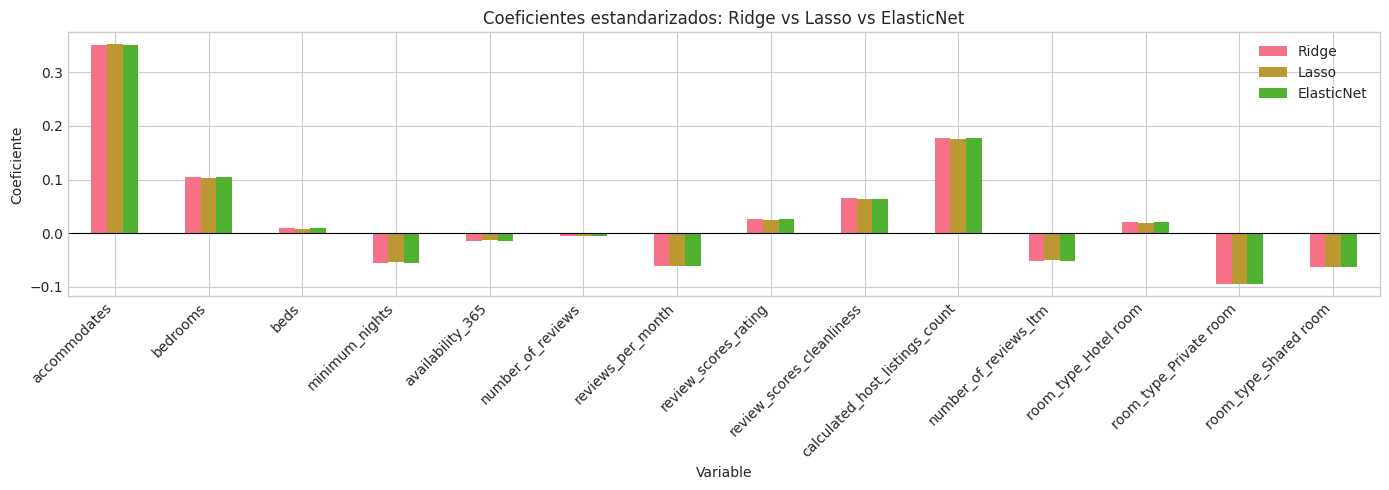

                       Feature     Ridge     Lasso  ElasticNet
                  accommodates  0.350870  0.352153    0.350490
                      bedrooms  0.103956  0.103322    0.103964
                          beds  0.009488  0.008238    0.009723
                minimum_nights -0.054888 -0.053844   -0.054787
              availability_365 -0.013926 -0.012995   -0.013825
             number_of_reviews -0.005904 -0.005396   -0.005905
             reviews_per_month -0.061408 -0.061078   -0.061328
          review_scores_rating  0.026158  0.025517    0.026115
     review_scores_cleanliness  0.064789  0.064378    0.064706
calculated_host_listings_count  0.177011  0.176386    0.176889
         number_of_reviews_ltm -0.051015 -0.050502   -0.050963
          room_type_Hotel room  0.020981  0.019959    0.020889
        room_type_Private room -0.095471 -0.094687   -0.095423
         room_type_Shared room -0.063660 -0.062722   -0.063564


In [26]:
# Comparar coeficientes entre modelos
coef_df = pd.DataFrame({
    "Feature": feature_candidates,
    "Ridge":      model_ridge.coef_,
    "Lasso":      model_lasso.coef_,
    "ElasticNet": model_en.coef_
})

coef_plot = coef_df.set_index("Feature")
coef_plot.plot(kind="bar", figsize=(14, 5))
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Coeficientes estandarizados: Ridge vs Lasso vs ElasticNet")
plt.xlabel("Variable")
plt.ylabel("Coeficiente")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(coef_df.to_string(index=False))

## 12. Evaluacion en Conjunto de Prueba

Aplicamos todos los modelos al conjunto de prueba y comparamos su desempeno usando:
- **R2**: proporcion de varianza explicada (mas alto es mejor)
- **RMSE**: error cuadratico medio (mas bajo es mejor)
- **MAE**: error absoluto medio (mas bajo es mejor, mas interpretable)

In [27]:
def metrics(y_true, y_pred, label):
    return {
        "Modelo": label,
        "R2 Test": round(r2_score(y_true, y_pred), 4),
        "RMSE": round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
        "MAE":  round(mean_absolute_error(y_true, y_pred), 4)
    }

results = [
    metrics(y_test, y_pred_uni_test,   "Univariado"),
    metrics(y_test, y_pred_multi_test, "Multivariado"),
    metrics(y_test, y_pred_ref_test,   "Refinado"),
    metrics(y_test, model_ridge.predict(X_test_sc), "Ridge"),
    metrics(y_test, model_lasso.predict(X_test_sc), "Lasso"),
    metrics(y_test, model_en.predict(X_test_sc),    "ElasticNet"),
]

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("R2 Test", ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

      Modelo  R2 Test   RMSE    MAE
Multivariado   0.4349 0.6355 0.4728
    Refinado   0.4349 0.6355 0.4728
       Lasso   0.4349 0.6355 0.4728
       Ridge   0.4349 0.6355 0.4728
  ElasticNet   0.4349 0.6355 0.4728
  Univariado   0.3288 0.6926 0.5138


## 13. Discusion y Seleccion del Mejor Modelo

Comparamos visualmente el desempeno de todos los modelos y seleccionamos el mejor basandonos en R2 test, RMSE y capacidad de generalizacion.

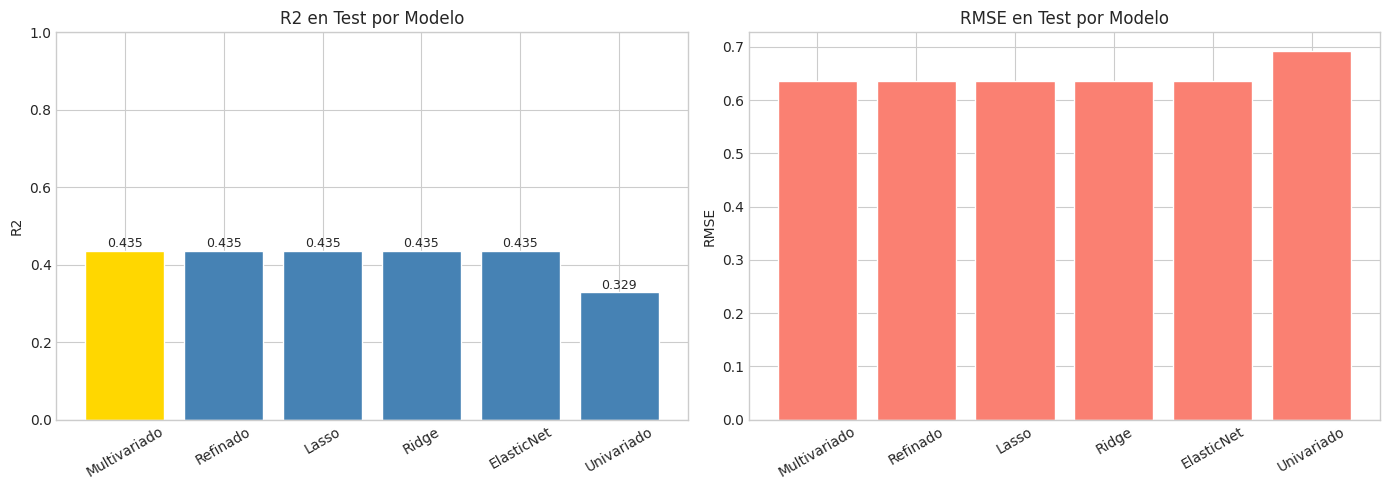

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart R2 por modelo
colors_bar = ["gold" if i == 0 else "steelblue" for i in range(len(results_df))]
axes[0].bar(results_df["Modelo"], results_df["R2 Test"], color=colors_bar, edgecolor="white")
axes[0].set_title("R2 en Test por Modelo")
axes[0].set_ylabel("R2")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=30)
for i, row in results_df.iterrows():
    axes[0].text(i, row["R2 Test"] + 0.01, f"{row[chr(82)+chr(50)+chr(32)+chr(84)+chr(101)+chr(115)+chr(116)]:.3f}", ha="center", fontsize=9)

# RMSE por modelo
axes[1].bar(results_df["Modelo"], results_df["RMSE"], color="salmon", edgecolor="white")
axes[1].set_title("RMSE en Test por Modelo")
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

Mejor modelo: Multivariado
Modelo     Multivariado
R2 Test          0.4349
RMSE             0.6355
MAE              0.4728


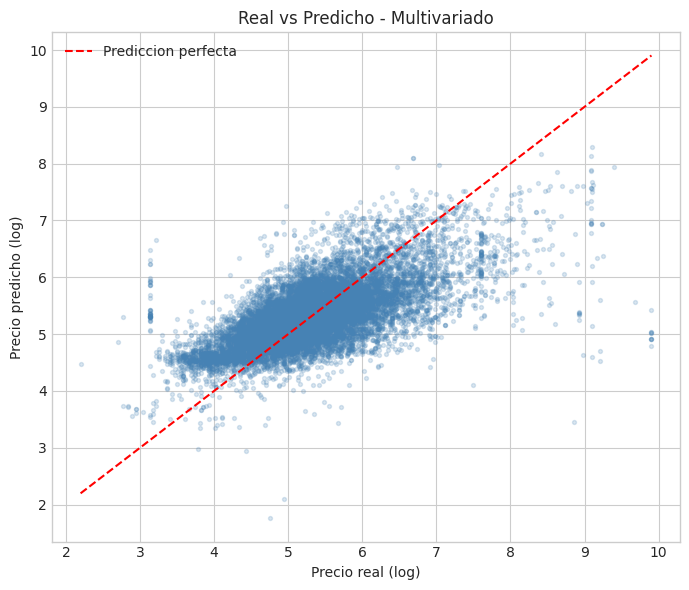

In [29]:
# Identificar el mejor modelo
best_model_name = results_df.iloc[0]["Modelo"]
print(f"Mejor modelo: {best_model_name}")
print(results_df.iloc[0].to_string())

# Scatter real vs predicho del mejor modelo
best_preds_map = {
    "Univariado":   y_pred_uni_test,
    "Multivariado": y_pred_multi_test,
    "Refinado":     y_pred_ref_test,
    "Ridge":        model_ridge.predict(X_test_sc),
    "Lasso":        model_lasso.predict(X_test_sc),
    "ElasticNet":   model_en.predict(X_test_sc),
}
best_preds = best_preds_map[best_model_name]

plt.figure(figsize=(7, 6))
plt.scatter(y_test, best_preds, alpha=0.2, s=8, color="steelblue")
mn, mx = float(y_test.min()), float(y_test.max())
plt.plot([mn,mx],[mn,mx], "r--", linewidth=1.5, label="Prediccion perfecta")
plt.xlabel("Precio real (log)")
plt.ylabel("Precio predicho (log)")
plt.title(f"Real vs Predicho - {best_model_name}")
plt.legend()
plt.tight_layout()
plt.show()

## Conclusiones Generales

1. **Variable mas influyente**: la capacidad de la propiedad () y el tipo de habitacion () son los predictores con mayor impacto en el precio, lo que tiene sentido en el contexto de Airbnb.

2. **Modelo univariado vs multiple**: el modelo con una sola variable explica una fraccion limitada de la variabilidad del precio. Al incluir multiples predictores el R2 mejora sustancialmente.

3. **Multicolinealidad**: algunas variables relacionadas con resenas presentaron VIF elevado, por lo que se removieron en el modelo refinado sin perder capacidad predictiva significativa.

4. **Regularizacion**: Ridge, Lasso y ElasticNet ofrecen resultados competitivos. Lasso destaca al llevar algunos coeficientes exactamente a cero, actuando como selector automatico de variables.

5. **Mejor modelo**: el modelo con mayor R2 en test y menor RMSE es el recomendado para SmartStay Advisors para estimar precios competitivos. La transformacion logaritmica del precio fue clave para estabilizar la varianza y mejorar el ajuste lineal.